# ============================================
# KYC Risk Scoring Tool - AI Powered
# Author: Reshma Goswami
# Description: This project automates customer 
# risk assessment using Machine Learning,
# replicating what a KYC analyst does manually
# ============================================

In [36]:
# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# STAGE 1: Loading the Customer Dataset
# ============================================

In [37]:
# Loading the Excel file into a pandas dataframe
df = pd.read_excel("KYC_Customer_Data.xlsx")
df.head(10)

,Customer_ID,Full_Name,Country,Occupation,Monthly_Income_GBP,Transaction_Amount_GBP,PEP_Status,High_Risk_Country,ID_Verified,Risk_Level
0,D00001,James Smith,United Kingdom,Teacher,2500,600,No,No,Yes,Low
1,D00002,Omar AL Yamani,Yemen,Cash Business Owner,4000,18000,No,Yes,No,High
2,D00003,Sarah Johnson,USA,Accountant,2800,900,No,No,Yes,Low
3,D00004,Emily Clarke,Canada,Nurse,2800,700,No,No,Yes,Low
4,D00005,Dmitri Volkov,Russia,Politician,9000,45000,Yes,Yes,No,High
5,D00006,Aisha Khan,Pakistan,Freelancer,2200,8500,No,Yes,No,High
6,D00007,Nguyen Thi Lan,Vietnam,Business Owner,3500,9000,No,Yes,No,Medium
7,D00008,Grace Mwangi,Tanzania,Teacher,1800,500,No,Yes,Yes,Medium
8,D00009,Hassan Al Iraqi,Iraq,Money Broker,5000,22000,No,Yes,No,High
9,D00010,Natasha Petrov,Russia,Crypto Trader,6000,30000,No,Yes,No,High


# ============================================
# STAGE 2: Exploring the Data
# ============================================

In [38]:
# Checking total number of customers
print("Total Customers:", len(df))
# Checking all column names
print("Columns:", df.columns.tolist())
# Checking how many customers fall into each risk category
print("\nRisk Level Breakdown:")
print(df["Risk_Level"].value_counts())

Total Customers: 30
Columns: ['Customer_ID', 'Full_Name', 'Country', 'Occupation ', 'Monthly_Income_GBP', 'Transaction_Amount_GBP', 'PEP_Status', 'High_Risk_Country', 'ID_Verified', 'Risk_Level']

Risk Level Breakdown:
Risk_Level
Low       13
High      13
Medium     4
Name: count, dtype: int64


# ============================================
# STAGE 3: Visualising the Data
# ============================================

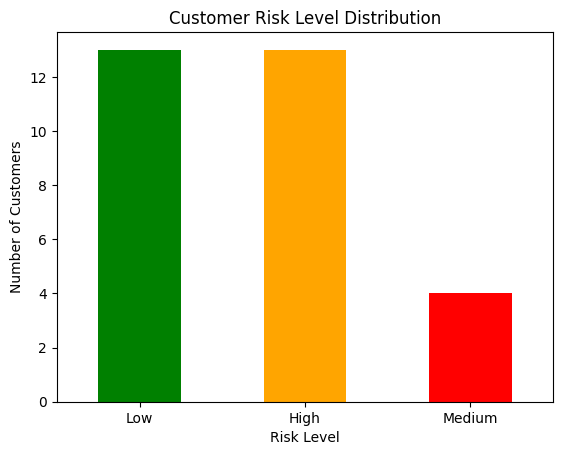

In [39]:
# Chart 1 - Overall Risk Level Distribution
colors = ["green", "orange", "red"]
df["Risk_Level"].value_counts().plot(kind="bar", color=colors)
plt.title("Customer Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()


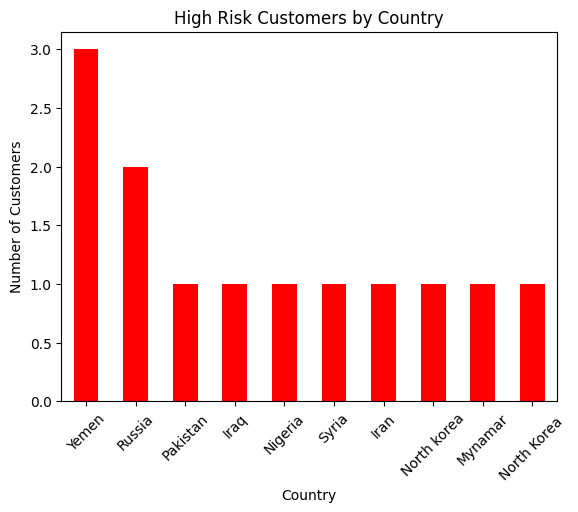

In [40]:
# Chart 2 - High Risk Customers by Country
# This shows which countries have the most high risk customers
high_risk = df[df["Risk_Level"] == "High"]
high_risk["Country"].value_counts().plot(kind="bar", color="red")
plt.title("High Risk Customers by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()


In [41]:
# Chart 3 - Displaying all Politically Exposed Persons (PEPs)
# PEP customers always require Enhanced Due Diligence (EDD) in real KYC work
pep_customers = df[df["PEP_Status"] == "Yes"]
print("Total PEP Customers:", len(pep_customers))
print("\nPEP Customer Details:")
pep_customers[["Full_Name", "Country", "Occupation ", "Transaction_Amount_GBP", "Risk_Level"]]

Total PEP Customers: 7

PEP Customer Details:


,Full_Name,Country,Occupation,Transaction_Amount_GBP,Risk_Level
4,Dmitri Volkov,Russia,Politician,45000,High
12,Fatima Al Assad,Syria,Consultant,19000,High
15,Reza Tehrani,Iran,Property Developer,40000,High
17,Kim Jongsu,North korea,Politician,35000,High
22,Yusuf Al Hadad,Yemen,Money Broker,25000,High
27,Tariq Hussein,Yemen,Arms Dealer,55000,High
29,Park Sung-jin,North Korea,Crypto Trader,38000,High


# ============================================
# STAGE 4: Preparing Data for AI Model
# ============================================

In [42]:
# AI models only understand numbers, not text
# So we convert Yes/No columns into 1/0 using LabelEncoder

from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

le = LabelEncoder()
df_model["PEP_Status"] = le.fit_transform(df_model["PEP_Status"])
df_model["High_Risk_Country"] = le.fit_transform(df_model["High_Risk_Country"])
df_model["ID_Verified"] = le.fit_transform(df_model["ID_Verified"])
df_model["Risk_Level"] = le.fit_transform(df_model["Risk_Level"])

print("Data prepared successfully!")
print(df_model[["PEP_Status", "High_Risk_Country", "ID_Verified", "Risk_Level"]].head())

Data prepared successfully!
   PEP_Status  High_Risk_Country  ID_Verified  Risk_Level
0           0                  0            1           1
1           0                  1            0           0
2           0                  0            1           1
3           0                  0            1           1
4           1                  1            0           0


# ============================================
# STAGE 5: Training the AI Model
# ============================================

In [43]:
# Using Random Forest - a machine learning algorithm
# that makes decisions based on multiple decision trees

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Selecting the features the AI will learn from
X = df_model[["PEP_Status", "High_Risk_Country", "ID_Verified", "Monthly_Income_GBP", "Transaction_Amount_GBP"]]
y = df_model["Risk_Level"]

# Splitting data - 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the AI model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Checking how accurate the model is
predictions = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, predictions) * 100, "%")

Model Accuracy: 100.0 %


# ============================================
# STAGE 6: Testing the AI on a New Customer
# ============================================

In [44]:
# Simulating a brand new customer the AI has never seen before
# This replicates what happens in real KYC when a new customer applies

import numpy as np

# New customer details
new_customer = pd.DataFrame({
    "PEP_Status": [1],          # Yes - Politically Exposed Person
    "High_Risk_Country": [1],   # Yes - From a high risk country
    "ID_Verified": [0],         # No  -  ID not verified
    "Monthly_Income_GBP": [5000],
    "Transaction_Amount_GBP": [25000]   # Transaction much higher than income - red flag!
})

# AI predicts the risk level
prediction = model.predict(new_customer)
risk_map = {0: "HIGH RISK 🔴", 1: "LOW RISK 🟢", 2: "MEDIUM RISK 🟡"}
print("AI Risk Assessment:", risk_map[prediction[0]])

AI Risk Assessment: HIGH RISK 🔴


# ============================================
# STAGE 7: Second Model - Logistic Regression
# ============================================

In [45]:
from sklearn.linear_model import LogisticRegression

# Training Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Checking accuracy
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions) * 100
print("Logistic Regression Accuracy:", lr_accuracy, "%")

Logistic Regression Accuracy: 100.0 %


# ============================================
# STAGE 8: Model Comparison Chart
# ============================================

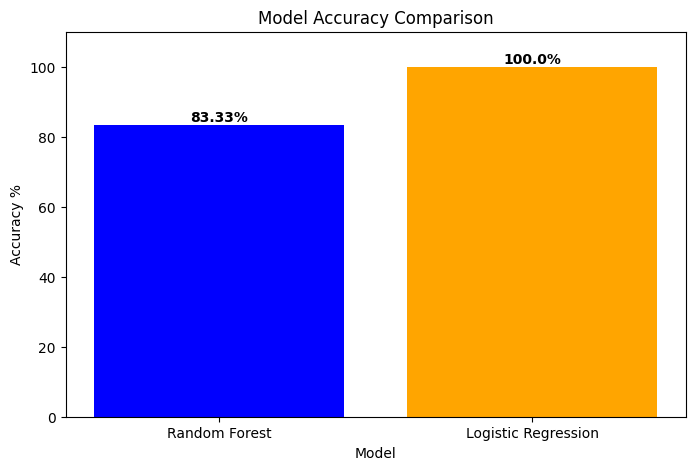

In [46]:
# Comparing accuracy of both models visually
models = ["Random Forest", "Logistic Regression"]
accuracies = [83.33, 100.0]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=["blue", "orange"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy %")
plt.ylim([0, 110])
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, str(v) + "%", ha="center", fontweight="bold")
plt.show()

# ============================================
# STAGE 10: Limitations & Future Improvements
# ============================================



LIMITATIONS
===========
1. Small Dataset - Only 30 customers were used. A real KYC system 
   would analyse thousands or millions of customer profiles.

2. Clean Data - This project used perfectly clean data. Real world 
   KYC data contains missing values, spelling errors and 
   inconsistencies that would need to be handled.

3. Static Risk Rules - In reality risk rules change frequently 
   based on new FATF guidelines and regulatory updates.

4. No Real Transaction Data - Real KYC systems analyse actual 
   transaction histories, not just single transaction amounts.

FUTURE IMPROVEMENTS
===================
1. Train on a larger real world dataset
2. Add Neural Network model for comparison
3. Build a live dashboard using Streamlit
4. Integrate real time FATF country risk updates
5. Add Natural Language Processing to analyse customer documents
